<a href="https://colab.research.google.com/github/AynicaChondammaBC/Aynica-Chondamma-BC/blob/main/Stock_Price_Prediction_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
!pip install yfinance tensorflow scikit-learn matplotlib pandas numpy

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [29]:
stock = input("Enter Stock Symbol (e.g., INFY.NS, TCS.NS, RELIANCE.NS, AAPL, TSLA): ").upper()
print("Selected Stock:", stock)

df = yf.download(stock,
                 start="2020-01-01",
                 end="2025-01-01")

df = df[['Close']]

print(df.head())

Enter Stock Symbol (e.g., INFY.NS, TCS.NS, RELIANCE.NS, AAPL, TSLA): TCS.NS
Selected Stock: TCS.NS


/tmp/ipykernel_4695/1004890306.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock,
[*********************100%***********************]  1 of 1 completed

Price             Close
Ticker           TCS.NS
Date                   
2020-01-01  1831.109985
2020-01-02  1822.704468
2020-01-03  1859.028931
2020-01-06  1858.860352
2020-01-07  1863.421509


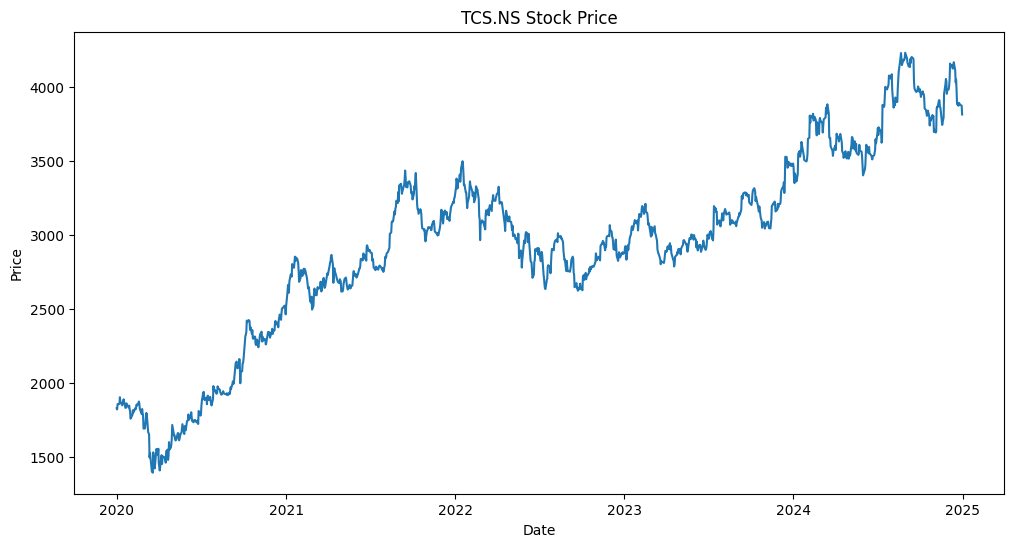

In [30]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'])
plt.title(f"{stock} Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [31]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df)

In [32]:
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

X = np.reshape(X, (X.shape[0], X.shape[1], 1))

print(X.shape)

(1178, 60, 1)


In [33]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [34]:
model = Sequential()

model.add(
    LSTM(
        units=50,
        return_sequences=True,
        input_shape=(X_train.shape[1],1)
    )
)

model.add(LSTM(units=50))

model.add(Dense(25))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 229ms/step - loss: 0.0247 - val_loss: 0.0024
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 131ms/step - loss: 0.0023 - val_loss: 0.0090
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0011 - val_loss: 0.0043
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 9.0910e-04 - val_loss: 0.0031
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 8.7736e-04 - val_loss: 0.0025
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 8.5001e-04 - val_loss: 0.0024
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 8.4098e-04 - val_loss: 0.0019
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 9.0665e-04 - val_loss: 0.0032
Epoch 9/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 9.3867e-04 - val_loss: 0.0035
Epoch 10/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 8.7320e-04 - val_loss: 0.0024


In [36]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))
actual = scaler.inverse_transform(y_test.reshape(-1,1))

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step


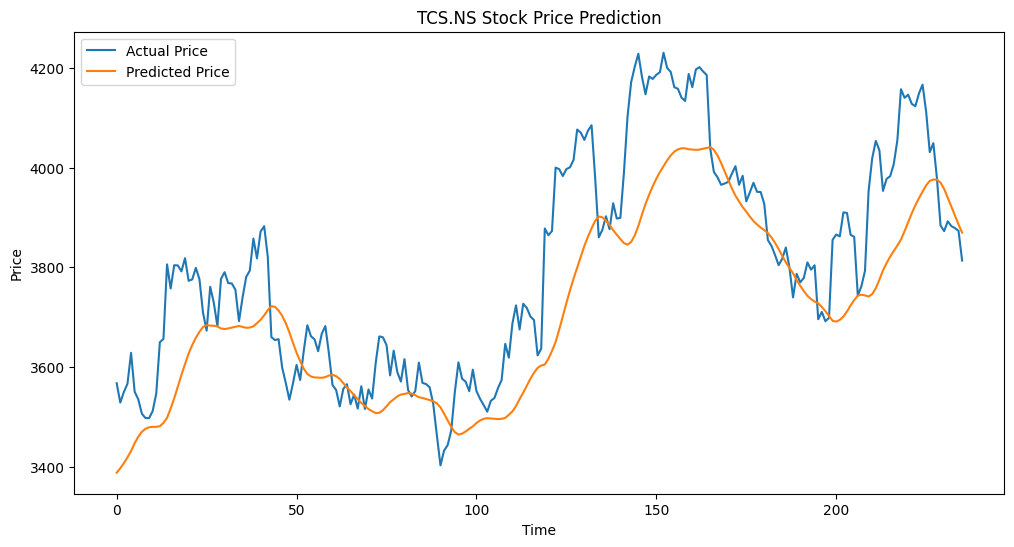

In [37]:
plt.figure(figsize=(12,6))

plt.plot(actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")

plt.title(f"{stock} Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price")

plt.legend()
plt.show()

In [38]:
rmse = np.sqrt(np.mean((predictions - actual) ** 2))

print("RMSE:", rmse)

RMSE: 139.08079325084046


In [39]:
last_60_days = scaled_data[-60:]

X_future = np.array([last_60_days])
X_future = X_future.reshape((1, 60, 1))

predicted_price = model.predict(X_future)

predicted_price = scaler.inverse_transform(predicted_price)

print("Predicted Next Day Price:", predicted_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Predicted Next Day Price: 3851.8616


In [40]:
future_days = 7

current_sequence = scaled_data[-60:]

predictions = []

for _ in range(future_days):

    X_future = np.array([current_sequence])
    X_future = X_future.reshape((1,60,1))

    pred = model.predict(X_future, verbose=0)

    predictions.append(pred[0][0])

    current_sequence = np.append(
        current_sequence[1:],
        pred
    )

future_prices = scaler.inverse_transform(
    np.array(predictions).reshape(-1,1)
)

print(f"\nPredicted Prices for Next {future_days} Days:\n")

for i, price in enumerate(future_prices):
    print(f"Day {i+1}: ₹{price[0]:.2f}")


Predicted Prices for Next 7 Days:

Day 1: ₹3851.86
Day 2: ₹3836.29
Day 3: ₹3822.03
Day 4: ₹3808.74
Day 5: ₹3796.17
Day 6: ₹3784.16
Day 7: ₹3772.61
